[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_3/03B-BiasAndVariance.ipynb)

# 03B — Bias and Variance
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 3, Notebook B — Hour 2**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`02C` produced a curve and left it unexplained. As the degree of a polynomial rose, the training
error fell all the way down while the test error fell, reached a minimum, and then climbed. We
called the two halves underfitting and overfitting, measured them with cross-validation, and moved
on.

This notebook asks *why the curve has that shape*. The answer splits a model's error into three
parts with different causes and different cures — and one of them cannot be cured at all.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain what is being averaged over when we speak of a model's bias and variance;
- describe bias as error from rigidity and variance as error from sensitivity to the sample;
- state the bias–variance decomposition and say why the three terms add;
- identify the **irreducible error**, and explain why no model can go below it;
- read the U-shaped test-error curve as the sum of a falling and a rising term;
- say which of the three terms more data changes, and which it does not.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 11,
})

rng = np.random.default_rng(0)

# The same experiment as 02C: a cubic, thirty noisy measurements of it.
def true_curve(t):
    return 0.5 * t**3 - 2 * t
noise_std = 2.5
n_points = 30

grid = np.linspace(-3, 3, 60)          # where we will evaluate the fitted models
truth_on_grid = true_curve(grid)


def one_dataset(size=n_points):
    """A fresh set of measurements from the same underlying curve, `size` of them."""
    x = np.sort(rng.uniform(-3, 3, size))
    return x, true_curve(x) + rng.normal(0, noise_std, size)


def fit_polynomial(x, y, degree):
    return make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(x.reshape(-1, 1), y)

# 1. The experiment we have not been running

Everything in `02C` was measured on **one** dataset. We split it, cross-validated it, and were
careful never to let the test points influence the fit — but there was only ever one set of thirty
measurements.

That is the right thing to do with real data, because thirty measurements is what you have. It is
the wrong thing for understanding *why* a model errs, because it confuses two quite different
failures:

- the model is the wrong shape, and would be wrong however much data you gave it;
- the model is the right shape, but this particular sample of thirty points pulled it somewhere it
  should not have gone.

Telling those apart needs something a real experiment never gives you: **many datasets from the
same source**. In simulation we can have them, because we know the curve the data came from.

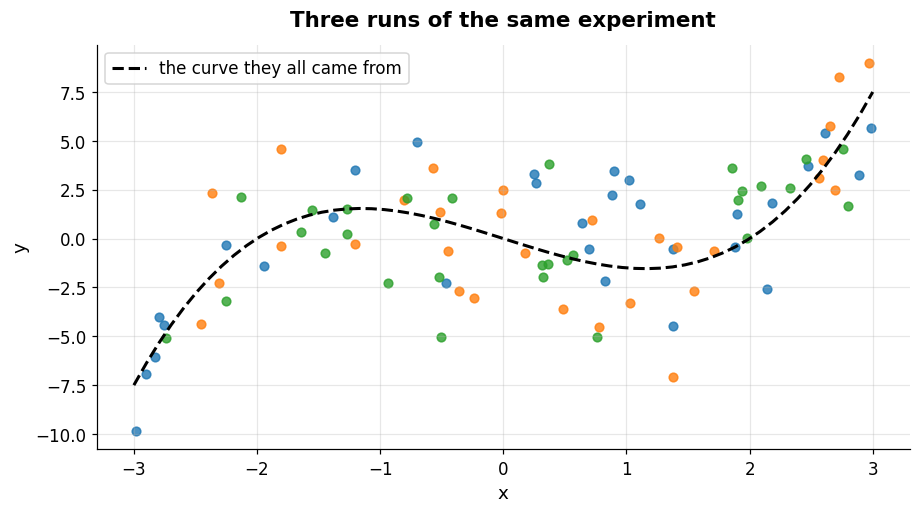

In [2]:
plt.figure(figsize=(8.5, 4.8))
for _ in range(3):
    x, y = one_dataset()
    plt.scatter(x, y, s=32, alpha=0.8)
plt.plot(grid, truth_on_grid, "k--", linewidth=2, label="the curve they all came from")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Three runs of the same experiment")
plt.legend()
plt.show()

Three repetitions of one experiment. The underlying curve is identical; only the noise differs.

A real study sees one of these. The question this notebook asks is what happens *across* them —
because that is where bias and variance live, and neither is visible in a single dataset.

# 2. Two ways to be wrong

Fit the same model form to many such datasets, and draw every fitted curve on one pair of axes. The
picture that comes out is the whole idea.

The next cell fits **degree 1** (a straight line) and **degree 9** to forty datasets each, and draws
all forty curves.

1. Which set of curves will be more tightly bunched?
2. Which will be centred on the true cubic?
3. Which model would you rather have, given one dataset and no way to see the truth?

**Think about your answer before running this cell.**

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6), sharey=True)

for axis, degree in zip(axes, [1, 3, 9]):
    for _ in range(40):
        x, y = one_dataset()
        axis.plot(grid, fit_polynomial(x, y, degree).predict(grid.reshape(-1, 1)),
                  color="tab:blue", alpha=0.18, linewidth=1)
    axis.plot(grid, truth_on_grid, "k--", linewidth=2.2, label="truth")
    axis.set_title(f"degree {degree}")
    axis.set_xlabel("x")
    axis.set_ylim(-16, 16)
    axis.legend(loc="upper left")

axes[0].set_ylabel("y")
fig.suptitle("Forty datasets, forty fits, three model forms", fontsize=15)
plt.show()

Read the three panels.

**Degree 1** is tightly bunched and wrong. Every one of the forty lines is close to every other, so
the sample barely matters — but none of them is near the true curve, because a straight line cannot
be. The error is in the *model form*, and forty more datasets would not help.

**Degree 9** is centred on the truth and wildly spread. Somewhere in the middle of that fan is a
curve close to the dashed line, but any single one of them wanders badly, especially near the edges.
The error is in the *sample*: this model is flexible enough to chase whichever thirty points it was
given.

**Degree 3** — the true shape — is both centred and tight.

Those two failures have names. The first is **bias**; the second is **variance**.

# 3. Bias: what the model gets wrong on average

Take the forty degree-1 fits and average them, point by point along $x$. That average is what the
model form predicts "in the long run", with the sample noise washed out.

**Bias** is the gap between that average prediction and the truth:

$$
\text{bias}(x) \;=\; \mathbb{E}_{\mathcal{D}}\bigl[\hat{f}_{\mathcal{D}}(x)\bigr] \;-\; f(x)
$$

where $\mathcal{D}$ is a dataset, $\hat{f}_{\mathcal{D}}$ the model fitted to it, and $f$ the true
curve. The expectation is over **datasets**, not over points — which is why one dataset can never
show it to you.

Bias measures rigidity. A model with high bias is systematically wrong in the same direction no
matter which sample it sees, because its shape cannot reach the truth.

# 4. Variance: how much the sample moves it

**Variance** is the spread of the fits about their own average, again point by point:

$$
\text{variance}(x) \;=\; \mathbb{E}_{\mathcal{D}}\Bigl[\bigl(\hat{f}_{\mathcal{D}}(x)
- \mathbb{E}_{\mathcal{D}}[\hat{f}_{\mathcal{D}}(x)]\bigr)^2\Bigr]
$$

It says nothing about being right. It says how much the answer depends on which thirty points you
happened to collect — the width of the fan in the degree-9 panel.

Variance measures sensitivity. A model with high variance gives a different answer to every
colleague who repeats the experiment, and none of them can tell from their own data that this is
happening.

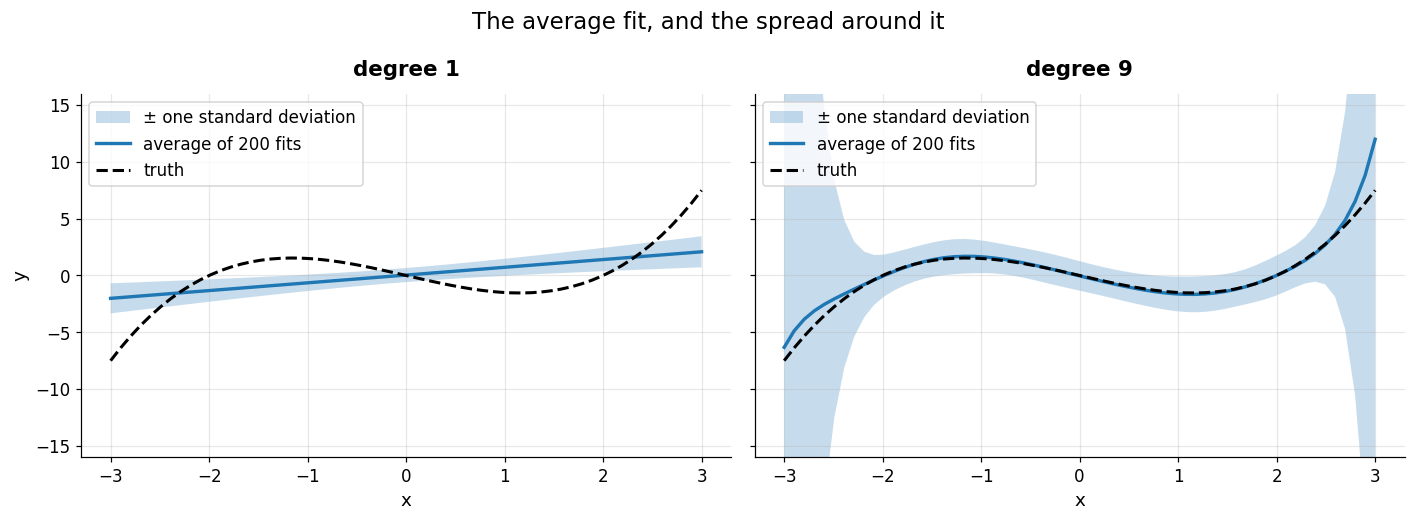

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for axis, degree in zip(axes, [1, 9]):
    predictions = np.array([fit_polynomial(*one_dataset(), degree).predict(grid.reshape(-1, 1))
                            for _ in range(200)])
    average = predictions.mean(axis=0)
    spread = predictions.std(axis=0)

    axis.fill_between(grid, average - spread, average + spread, alpha=0.25,
                      label="± one standard deviation")
    axis.plot(grid, average, linewidth=2.2, label="average of 200 fits")
    axis.plot(grid, truth_on_grid, "k--", linewidth=2, label="truth")
    axis.set_title(f"degree {degree}")
    axis.set_xlabel("x")
    axis.set_ylim(-16, 16)
    axis.legend(loc="upper left")

axes[0].set_ylabel("y")
fig.suptitle("The average fit, and the spread around it", fontsize=15)
plt.show()

The same two failures, separated.

On the left the average (solid) is far from the truth (dashed) and the band is narrow: **bias
without variance**. On the right the average lies almost on top of the truth while the band is
wide: **variance without bias**. The degree-9 model is right on average and unreliable in
particular — which is worth restating, because "right on average" is no comfort at all when you
have one dataset.

<div class="alert alert-success">
<b>Mini-exercise 1 — Where does the fan open?</b><br>
Look again at the right-hand panel.
<br><br>
1. Where along $x$ is the band widest? Where is it narrowest?<br>
2. What is different about those regions — how many measurements does a typical dataset place near
   each?<br>
3. Repeat the figure with <code>n_points = 100</code> instead of 30. What happens to the width of
   the band, and to the position of the average?<br>
4. Which of bias and variance did that change, and which did it leave alone?
</div>

In [5]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 5. The part no model can remove

There is a third source of error, and it has nothing to do with the model.

The measurements are the true curve plus noise. Even a model that recovered $f$ exactly — the true
cubic, with the true coefficients — would still miss each observation by whatever the noise was on
that observation. That gap is the **irreducible error**, or **noise floor**:

$$
\sigma^2 \;=\; \mathbb{E}\bigl[(y - f(x))^2\bigr]
$$

Here we built the data ourselves, so we know it exactly: `noise_std` is 2.5, and the floor is
$2.5^2 = 6.25$.

This is the quantity `02B` §10.5 ran into and did not name. Three flowers there shared identical
petal measurements while belonging to two different species — so any model, given those two
features, is wrong about at least one of them. That is irreducible error in a classification
problem: not a failure of logistic regression, but a statement about what the features contain.

> No amount of data, and no choice of model, goes below the noise floor. The only way down is to
> measure something else — a better instrument, or an additional feature.

The figure below draws it. The dashed line is the truth; each red segment is the distance from the
truth to what was actually measured. Those segments are what noise did, and no model — not even the
right one with the right coefficients — can shorten them.

The numbers underneath make the same point twice. One dataset's mean squared gap is 8.51, which is
not 6.25; averaged over four hundred datasets it settles at 6.42. The floor is a property of the
experiment, but any single sample only estimates it.


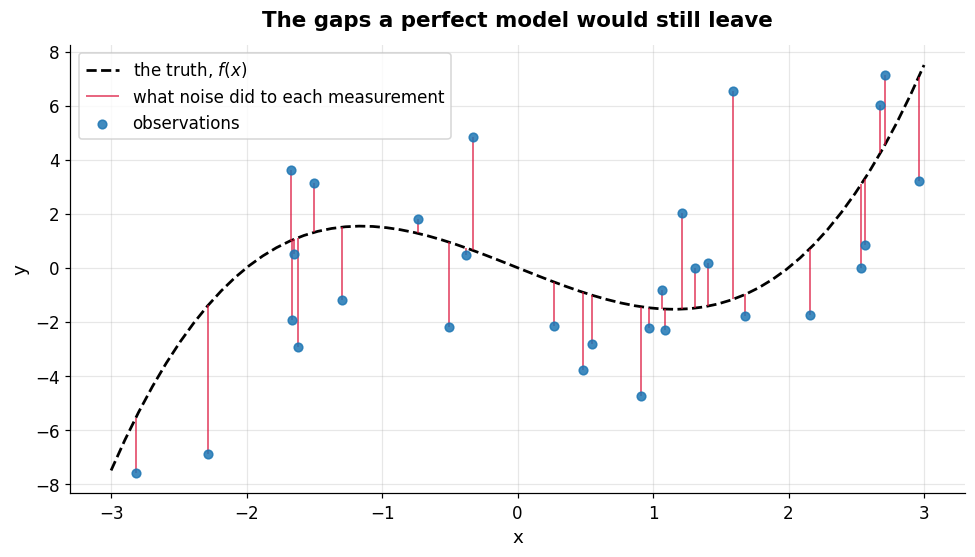

mean squared gap, this one dataset :   8.51
mean squared gap, over 400 datasets:   6.42
the noise floor, noise_std squared :   6.25


In [6]:
fresh_x, fresh_y = one_dataset()

plt.figure(figsize=(9, 5.2))
plt.plot(grid, truth_on_grid, "k--", linewidth=1.8, label="the truth, $f(x)$")
plt.vlines(fresh_x, true_curve(fresh_x), fresh_y, color="crimson", linewidth=1.2,
           alpha=0.7, label="what noise did to each measurement")
plt.scatter(fresh_x, fresh_y, s=32, zorder=3, alpha=0.85, label="observations")
plt.xlabel("x")
plt.ylabel("y")
plt.title("The gaps a perfect model would still leave")
plt.legend()
plt.show()

# One dataset's gaps are a noisy estimate of the floor, so average over many
measured_floor = np.mean([np.mean((y - true_curve(x)) ** 2) for x, y in
                          (one_dataset() for _ in range(400))])
print(f"mean squared gap, this one dataset : "
      f"{np.mean((fresh_y - true_curve(fresh_x)) ** 2):6.2f}")
print(f"mean squared gap, over 400 datasets: {measured_floor:6.2f}")
print(f"the noise floor, noise_std squared : {noise_std ** 2:6.2f}")

# 6. The decomposition

The three parts are not merely a way of talking. For squared error they **add**, exactly:

$$
\underbrace{\mathbb{E}\bigl[(y - \hat{f}(x))^2\bigr]}_{\text{expected test error}}
\;=\;
\underbrace{\bigl(\mathbb{E}[\hat{f}(x)] - f(x)\bigr)^2}_{\text{bias}^2}
\;+\;
\underbrace{\mathbb{E}\bigl[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\bigr]}_{\text{variance}}
\;+\;
\underbrace{\sigma^2}_{\text{noise}}
$$

Everything is at a fixed $x$, and every expectation is over datasets. Averaging the whole equation
over $x$ gives the expected test error of the model form.

The identity is worth trusting rather than believing, so the next cell computes all four quantities
independently — the three terms from 200 refits, and the test error by actually testing — and puts
them side by side.

In [7]:
degrees = range(1, 8)
n_datasets = 200

results = []
for degree in degrees:
    predictions, measured_error = [], []
    for _ in range(n_datasets):
        model = fit_polynomial(*one_dataset(), degree)
        predicted = model.predict(grid.reshape(-1, 1))
        predictions.append(predicted)
        fresh_test = truth_on_grid + rng.normal(0, noise_std, len(grid))
        measured_error.append(np.mean((fresh_test - predicted) ** 2))

    predictions = np.array(predictions)
    bias_squared = np.mean((predictions.mean(axis=0) - truth_on_grid) ** 2)
    variance = np.mean(predictions.var(axis=0))
    results.append((degree, bias_squared, variance, noise_std**2, np.mean(measured_error)))

print(f"{'degree':>7}{'bias^2':>10}{'variance':>10}{'noise':>8}{'sum':>10}{'measured':>10}")
for degree, b, v, n, measured in results:
    print(f"{degree:>7}{b:>10.2f}{v:>10.2f}{n:>8.2f}{b + v + n:>10.2f}{measured:>10.2f}")

 degree    bias^2  variance   noise       sum  measured
      1      4.61      0.69    6.25     11.55     11.61
      2      4.75      1.57    6.25     12.58     12.50
      3      0.01      1.16    6.25      7.42      7.56
      4      0.00      1.74    6.25      8.00      7.98
      5      0.02      3.21    6.25      9.47      9.45
      6      0.01      6.69    6.25     12.95     13.03
      7      0.35     53.49    6.25     60.09     59.68


The last two columns agree at every degree, to within the sampling error of using 200 datasets
rather than infinitely many. The decomposition is an identity, not an analogy.

Now read down the columns, which is where the U-shape comes from.

**Bias² falls and then stops.** It is large at degree 1 and 2, where a line and a parabola cannot
be a cubic. At degree 3 it collapses essentially to zero, because the model form now *contains* the
truth. Adding degrees beyond 3 cannot reduce it further — there is nothing left to remove.

**Variance rises throughout, and then accelerates.** Every extra coefficient is one more quantity
estimated from the same thirty points, and each is estimated a little worse than the last.

**Noise is constant**, because it has nothing to do with the model.

One detail in the table is worth a glance: degree 2 is slightly *worse* than degree 1. The reason is
the general one, and it is the sharpest statement of what "flexibility" costs:

> A term the truth does not need buys no reduction in bias, and pays for itself in variance.

Here, over the range we sample, the best quadratic coefficient turns out to be zero. So the
quadratic term buys nothing: bias² stays where it was, while the one extra coefficient estimated
from the same thirty points raises the variance. The total goes up.

The same logic is why degree 4 and 5 are worse than degree 3, and it is worth separating from the
other reason a model can be too flexible. Beyond degree 3 the extra terms are *unnecessary*; below
degree 3 the model is *unable*. Both raise the error, and only the second is bias.

> Whether a term is "needed" is not a property of the formula alone — it depends on the range over
> which you sample. Over the $[-3, 3]$ used here, the best quadratic coefficient of this curve turns
> out to be zero. Sample $x \in [0, 3]$ instead and it becomes $+2.25$, and degree 2 then reduces
> bias sharply and *beats* degree 1. Same curve, same noise, different answer. Mini-exercise 2 asks
> you to check it.

So the total is a falling term plus a rising one plus a constant — and a sum of that shape has a
minimum in the middle. That is the whole explanation of `02C`'s curve.

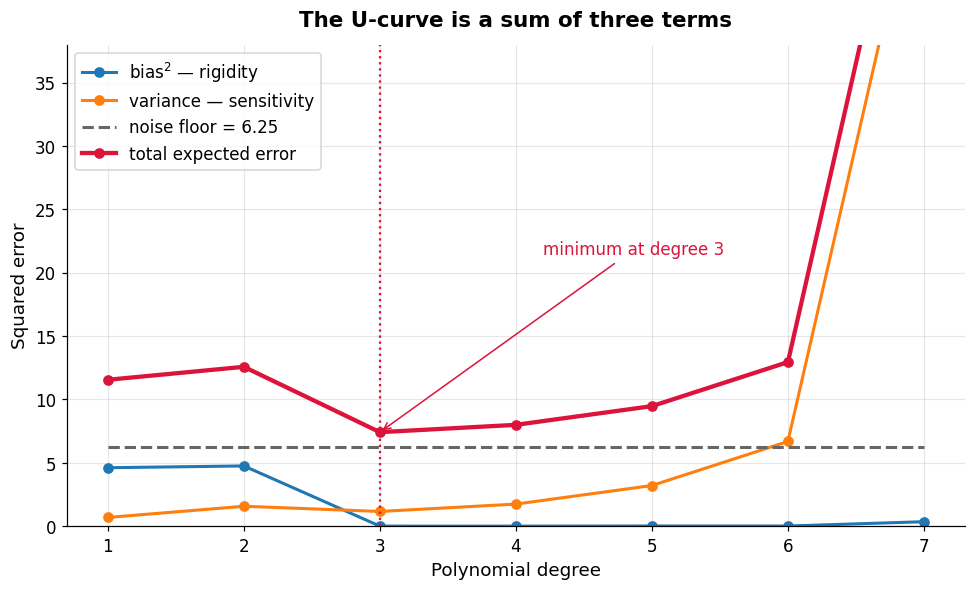

In [8]:
degree_values = [r[0] for r in results]
bias_curve = [r[1] for r in results]
variance_curve = [r[2] for r in results]
noise_curve = [r[3] for r in results]
total_curve = [r[1] + r[2] + r[3] for r in results]

plt.figure(figsize=(9, 5.5))
plt.plot(degree_values, bias_curve, marker="o", linewidth=2, label="bias$^2$ — rigidity")
plt.plot(degree_values, variance_curve, marker="o", linewidth=2, label="variance — sensitivity")
plt.plot(degree_values, noise_curve, linestyle="--", linewidth=2, color="0.4",
         label=f"noise floor = {noise_std**2:.2f}")
plt.plot(degree_values, total_curve, marker="o", linewidth=2.8, color="crimson",
         label="total expected error")

best = degree_values[int(np.argmin(total_curve))]
plt.axvline(best, color="crimson", linestyle=":", linewidth=1.5)
plt.annotate(f"minimum at degree {best}", xy=(best, min(total_curve)),
             xytext=(best + 1.2, min(total_curve) + 14), fontsize=11, color="crimson",
             arrowprops={"arrowstyle": "->", "color": "crimson"})

plt.xlabel("Polynomial degree")
plt.ylabel("Squared error")
plt.title("The U-curve is a sum of three terms")
plt.ylim(0, 38)
plt.legend()
plt.show()

The red curve is `02C`'s test error, and the two coloured curves beneath it are what it is made of.

To the left of the minimum, bias dominates: the model is too rigid, and the cure is more
flexibility. To the right, variance dominates: the model is flexible enough and the data are not
sufficient to pin it down, and the cure is *less* flexibility, or more data. The minimum is where
one stops falling faster than the other rises.

Note also what the red curve never does: it never goes below the dashed line. It cannot.

> **Underfitting** is another word for bias-dominated. **Overfitting** is another word for
> variance-dominated. `02C` named the two halves; this is what is happening in each.

# 7. What changes each term

The three terms answer to different remedies, which is the practical reason for separating them.

The next cell holds the degree fixed at 6 — comfortably into the overfitting half of the curve —
and increases the number of training points from 30 to 480.

1. What will happen to the variance?
2. What will happen to the bias²?
3. Will the total error reach the noise floor?

**Think about your answer before running this cell.**

In [ ]:
recorded = []
print(f"{'training points':>16}{'bias^2':>10}{'variance':>12}{'total':>12}")
for size in [30, 60, 120, 240, 480]:
    predictions = np.array([fit_polynomial(*one_dataset(size), 6).predict(grid.reshape(-1, 1))
                            for _ in range(200)])
    bias_squared = np.mean((predictions.mean(axis=0) - truth_on_grid) ** 2)
    variance = np.mean(predictions.var(axis=0))
    recorded.append((size, bias_squared, variance))
    print(f"{size:>16}{bias_squared:>10.3f}{variance:>12.3f}"
          f"{bias_squared + variance + noise_std**2:>12.2f}")

sizes, bias_curve, variance_curve = np.array(recorded).T
plt.figure(figsize=(9, 5.2))
plt.plot(sizes, variance_curve, marker="o", linewidth=2.2, label="variance")
plt.plot(sizes, bias_curve, marker="o", linewidth=2.2, label="bias$^2$")
plt.plot(sizes, bias_curve + variance_curve + noise_std**2, marker="o", linewidth=2.6,
         color="crimson", label="total")
plt.axhline(noise_std**2, color="0.4", linestyle="--", linewidth=1.6,
            label=f"noise floor = {noise_std**2:.2f}")
plt.xscale("log")
plt.yscale("log")
plt.xticks(sizes, [f"{int(s)}" for s in sizes])
plt.xlabel("training points")
plt.ylabel("squared error  (log scale)")
plt.title("More data buys variance, and buys nothing else")
plt.legend()
plt.show()

Variance falls steadily as the training set grows: **17.7 at thirty points, 1.16 at sixty, and 0.10
at four hundred and eighty**. Bias² does not — it starts near zero and stays there, because a
degree-6 polynomial can represent a cubic exactly, and no amount of data changes what a model form
is capable of. The total falls with the variance and stops just above the noise floor of 6.25.

> The thirty-point row is a fresh estimate of a quantity section 6 already tabulated — degree 6, thirty
> points — and it will not match that table exactly. Both are averages over 200 datasets, and
> variance at degree 6 is the hardest of these quantities to pin down with so few.

That is the general rule, and it is worth stating plainly:

| Term | Reduced by | Not reduced by |
|---|---|---|
| **Bias²** | a model form that can represent the truth: more flexibility, better features | more data |
| **Variance** | more data; less flexibility; regularization (`03C`) | a better model form |
| **Noise** | measuring something else | anything you do to the model |

This explains an observation that otherwise looks paradoxical. A model that overfits badly on
thirty points may be exactly the right model on three thousand — the flexibility that was
unaffordable becomes affordable once the data can pin it down. It is also why "which model is
best?" has no answer independent of how much data you have.

And it explains the shape of `01A`'s dataset-size figure, which showed deep learning worst on small
data and best on large: very flexible models are variance-dominated until the data catch up.

<div class="alert alert-success">
<b>Mini-exercise 2 — Moving the minimum</b><br>
Using the machinery above:
<br><br>
1. Recompute the bias–variance table with <code>n_points = 200</code> instead of 30.<br>
2. Where is the minimum of the total error now? Has it moved, and in which direction?<br>
3. Explain the direction it moved in terms of which of the three terms changed.<br>
4. What would happen to the minimum if you instead halved <code>noise_std</code>?<br>
5. Now change the sampling range from $[-3, 3]$ to $[0, 3]$, leaving the true curve and everything
   else alone. Recompute bias² for degrees 1, 2 and 3. Is degree 2 still worse than degree 1? Explain
   what changed, given that the true curve did not.
</div>

In [10]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 8. What this buys you in practice

The decomposition is a way of understanding, not a procedure. You cannot compute it on real data:
every term needs either the true curve or many datasets, and a real study has one dataset and no
truth.

What it gives you instead is a diagnosis, and the diagnosis is what tells you which lever to pull.

- **Training error low, test error high** — the gap is variance. Get more data, reduce flexibility,
  or regularize.
- **Training error high, test error high and close to it** — the model cannot even fit what it has
  seen. That is bias, and more data will not touch it.
- **Both close to the noise floor** — as good as this problem allows, if you know the floor.

`02C` already supplied the measuring instrument. Cross-validation estimates the test error without
knowing the truth, and the training-versus-test gap it exposes is what distinguishes the first case
from the second.

The third case needs the floor, which real problems rarely hand you. Repeated measurements of the
same sample are the usual way to estimate it: their spread is a direct estimate of $\sigma$, and it
tells you when to stop improving the model and start improving the instrument.

# 9. Common pitfalls

**Reading bias and variance off one dataset.** Both are expectations over datasets. One fitted
curve tells you nothing about either — which is exactly why the notebook needed a simulation.

**Believing "unbiased" means "good".** The degree-9 model is essentially unbiased and much worse
than the degree-3 one. An unbiased model with large variance is right on average and wrong every
time.

**Chasing the noise floor.** Effort spent driving the error below $\sigma^2$ is effort spent
fitting noise. If you know the floor, know when you have reached it.

**Assuming more data fixes everything.** It shrinks variance and does nothing to bias. A linear
model on a curved relationship is exactly as wrong on a million points as on thirty.

**Assuming a more flexible model is a better model.** It trades bias for variance. Whether that is
a good trade depends entirely on how much data you have, which is why `01A` insisted the question is
"which assumptions match my data?".

# 10. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — Bias and variance for a different truth</b><br>
Replace <code>true_curve</code> with something a polynomial cannot represent exactly — say
$f(x) = \sin(2x)$ — keeping everything else the same.
<br><br>
1. Recompute the bias–variance table over degrees 1 to 8.<br>
2. Does bias² ever collapse to zero as it did for the cubic? Why not?<br>
3. Where is the minimum now?<br>
4. What does this say about the phrase "the correct model"?
</div>

In [11]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — The noise floor in the table</b><br>
1. Re-run the degree sweep with <code>noise_std = 0.5</code>.<br>
2. What happens to the noise column, to the variance column, and to the position of the minimum?<br>
3. Explain why the variance changed, given that the model form did not.<br>
4. If a collaborator reports a test MSE of 0.3 on data whose measurement error is known to be 0.8,
   what should you conclude?
</div>

In [12]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Bagging, in advance</b><br>
Section 2's figure showed forty degree-9 fits scattered around the truth, and section 4 showed that
their *average* lies almost on it.
<br><br>
1. Build 50 datasets, fit degree 9 to each, and average the 50 predictions on the grid.<br>
2. Compute the squared error of that averaged prediction, and compare it with the typical error of
   a single degree-9 fit.<br>
3. Which of the three terms did averaging reduce? Which did it leave alone?<br>
4. You have just built, by hand, the idea behind the random forests of Class 4. What is the
   practical difficulty with doing this on real data, where you have one dataset rather than 50?
</div>

In [13]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- Bias and variance are expectations over **datasets**. Neither is visible in the single dataset a
  real experiment provides, which is why they had to be shown by simulation.
- **Bias** is error from rigidity: the model form cannot reach the truth, and more data will not
  help. **Variance** is error from sensitivity: the fit follows the particular sample it was given.
- For squared error the two, plus the **noise floor**, add up exactly to the expected test error.
  The computed sum matched the measured error at every degree.
- The U-shaped curve of `02C` is a falling bias term plus a rising variance term plus a constant.
  Underfitting is bias-dominated; overfitting is variance-dominated.
- The **irreducible error** is the floor no model passes. It is what `02B` §10.5 met when two
  species shared identical measurements: a statement about the features, not about the model.
- More data reduces variance and not bias. A model that overfits on thirty points may be the right
  model on three thousand.
- You cannot compute the decomposition on real data. What you can do is diagnose which term
  dominates, from the gap between training and test error, and pull the corresponding lever.

# Optional preparation for the next notebook

Before the next notebook, students should be comfortable with:

- the distinction between bias and variance, and what each responds to;
- reading a training-versus-test error gap as evidence of variance;
- the idea of a noise floor.

`03C` takes the practical consequence. If variance is the problem and more data is not available,
the remaining lever is to restrain the model — to allow flexibility while penalising its use.
That is **regularization**, and it turns the discrete choice of degree made here into a continuous
dial. It also settles two debts: why feature scaling matters once coefficients are penalised, and
why `02B`'s `LogisticRegression` was quietly regularized all along.